# Reward Model Debug

In [1]:
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv

import sumo_rl_ego as sre
from human_feedback_rl.common.trajectory_generators import TrajectoryGeneratorFromAgent

from loadings import load_reward_ensemble
from plot_functions import plot_scatter, plot_reward_curves

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

Plot functions loaded OK


In [2]:
CHECKPOINT_DIR = Path("/home/ricca/projects/sumo-human-feedback-rl/outputs/ppo_chri seg_len=1 tot_queries=20500 hard_labels=False seed=0_01/checkpoint_0050")


env = sre.make_vec_env(
    "HighwayEgo-v0",
    n_envs=4,
    base_seed=0,
    ego="continuous",
    reward="fast"
)

reward_model = load_reward_ensemble(
    CHECKPOINT_DIR / "reward_model.pt",
    env.observation_space,
    env.action_space,
)

# Passa env a load() per fare l'override di n_envs (il modello era salvato con n_envs=4)
agent = PPO.load(CHECKPOINT_DIR / "agent.zip", env=env, device="cpu")

trajectory_generator = TrajectoryGeneratorFromAgent(
    agent=agent,
    reward_model=reward_model,
    venv=env,
)

In [3]:
N_STEPS = 10000
trajectories = trajectory_generator.sample(N_STEPS, 0)

In [4]:
def score_trajectory(traj) -> float:
    obs         = np.array([t.observation for t in traj])
    acts        = np.array([t.action for t in traj])
    next_status = np.array([t.next_status for t in traj])
    done        = np.array([float(t.done) for t in traj])
    return reward_model.predict(obs, acts, next_status, done).sum()

# next_status: 7-dim one-hot [arrived, collided, off_road, timeout, running, teleported, removed_unknown]
STATUS_ARRIVED  = 0
STATUS_COLLIDED = 1
STATUS_OFFROAD  = 2
STATUS_TIMEOUT  = 3

terminal_statuses = [np.argmax(traj[-1].next_status) for traj in trajectories]

n_episodes = len(trajectories)
n_arrived  = sum(s == STATUS_ARRIVED  for s in terminal_statuses)
n_collided = sum(s == STATUS_COLLIDED for s in terminal_statuses)
n_offroad  = sum(s == STATUS_OFFROAD  for s in terminal_statuses)
n_timeout  = sum(s == STATUS_TIMEOUT  for s in terminal_statuses)

true_rewards  = [traj.total_reward()              for traj in trajectories]
model_rewards = [score_trajectory(traj)           for traj in trajectories]
lengths       = [len(traj)                        for traj in trajectories]

print(f"Episodi totali:        {n_episodes}")
print(f"Lunghezza media:       {float(np.mean(lengths)):.1f}")
print(f"Reward media:          {float(np.mean(true_rewards)):.3f}")
print(f"Reward predetta media: {float(np.mean(model_rewards)):.3f}")
print()
print(f"Terminazioni:")
print(f"  Arrived:  {n_arrived:3d}  ({100 * n_arrived  / n_episodes:.1f}%)")
print(f"  Collided: {n_collided:3d}  ({100 * n_collided / n_episodes:.1f}%)")
print(f"  Off-road: {n_offroad:3d}  ({100 * n_offroad  / n_episodes:.1f}%)")
print(f"  Timeout:  {n_timeout:3d}  ({100 * n_timeout  / n_episodes:.1f}%)")

Episodi totali:        60
Lunghezza media:       172.6
Reward media:          4.801
Reward predetta media: 275.862

Terminazioni:
  Arrived:   30  (50.0%)
  Collided:  24  (40.0%)
  Off-road:   6  (10.0%)
  Timeout:    0  (0.0%)


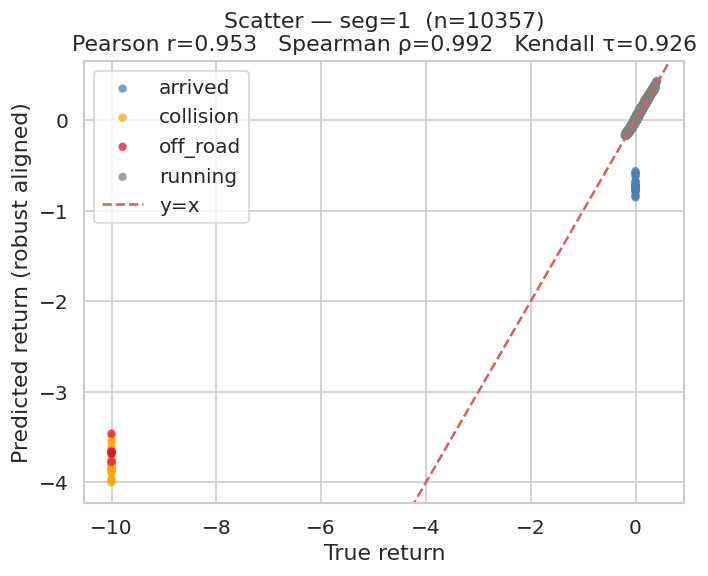

[seg=1] Pearson=0.953  Spearman=0.992  Kendall=0.926  n=10357


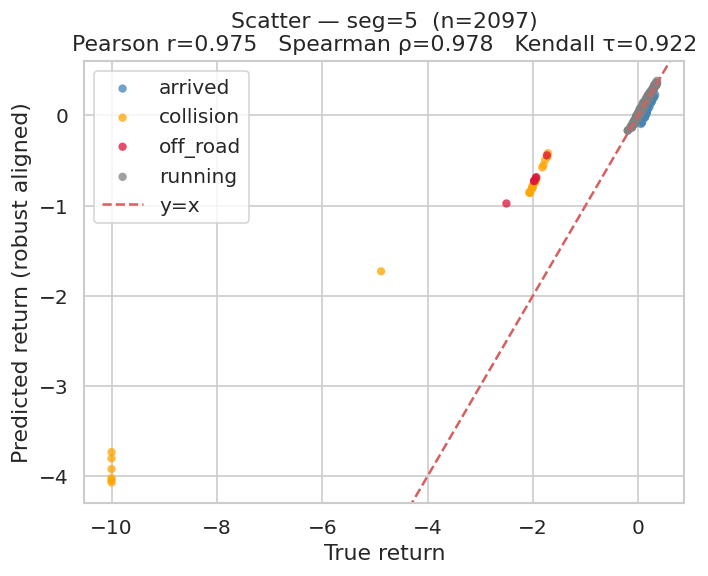

[seg=5] Pearson=0.975  Spearman=0.978  Kendall=0.922  n=2097


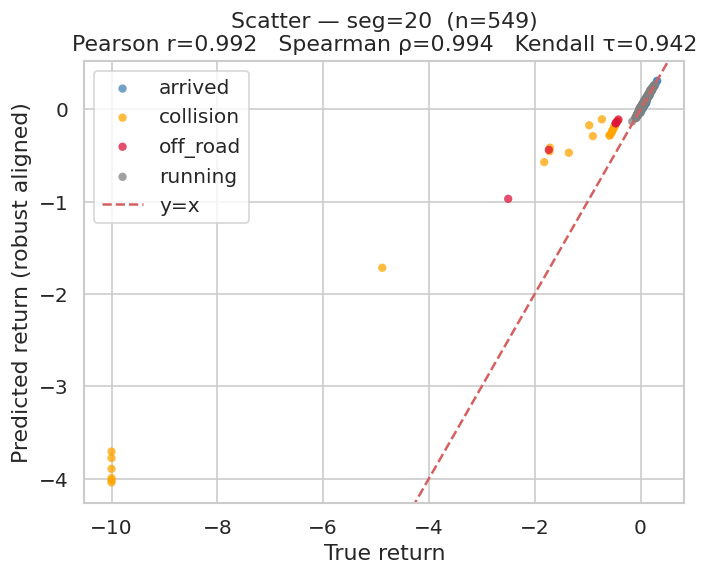

[seg=20] Pearson=0.992  Spearman=0.994  Kendall=0.942  n=549


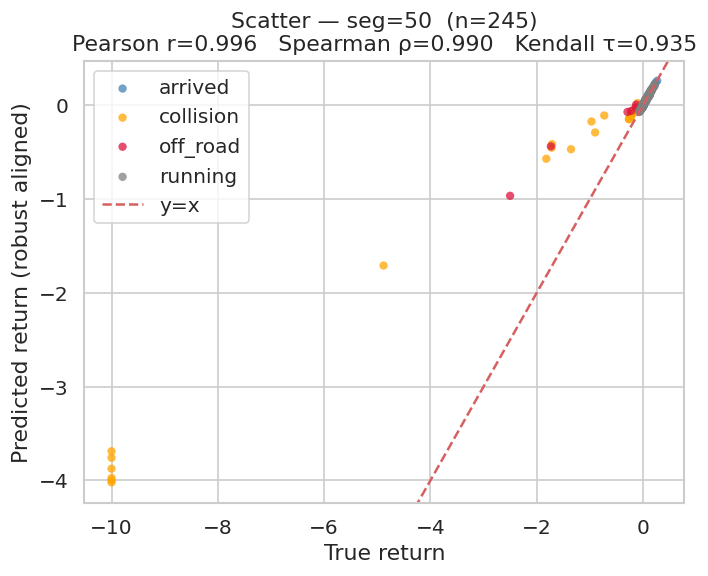

[seg=50] Pearson=0.996  Spearman=0.990  Kendall=0.935  n=245


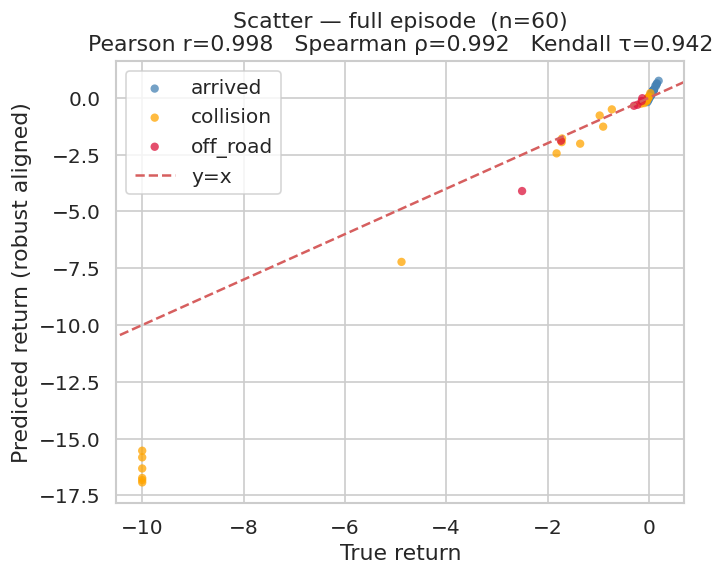

[full episode] Pearson=0.998  Spearman=0.992  Kendall=0.942  n=60


In [5]:
for seg_len in [1, 5, 20, 50, None]:
    plot_scatter(trajectories, reward_model, segment_length=seg_len, normalize=True, robust=True)

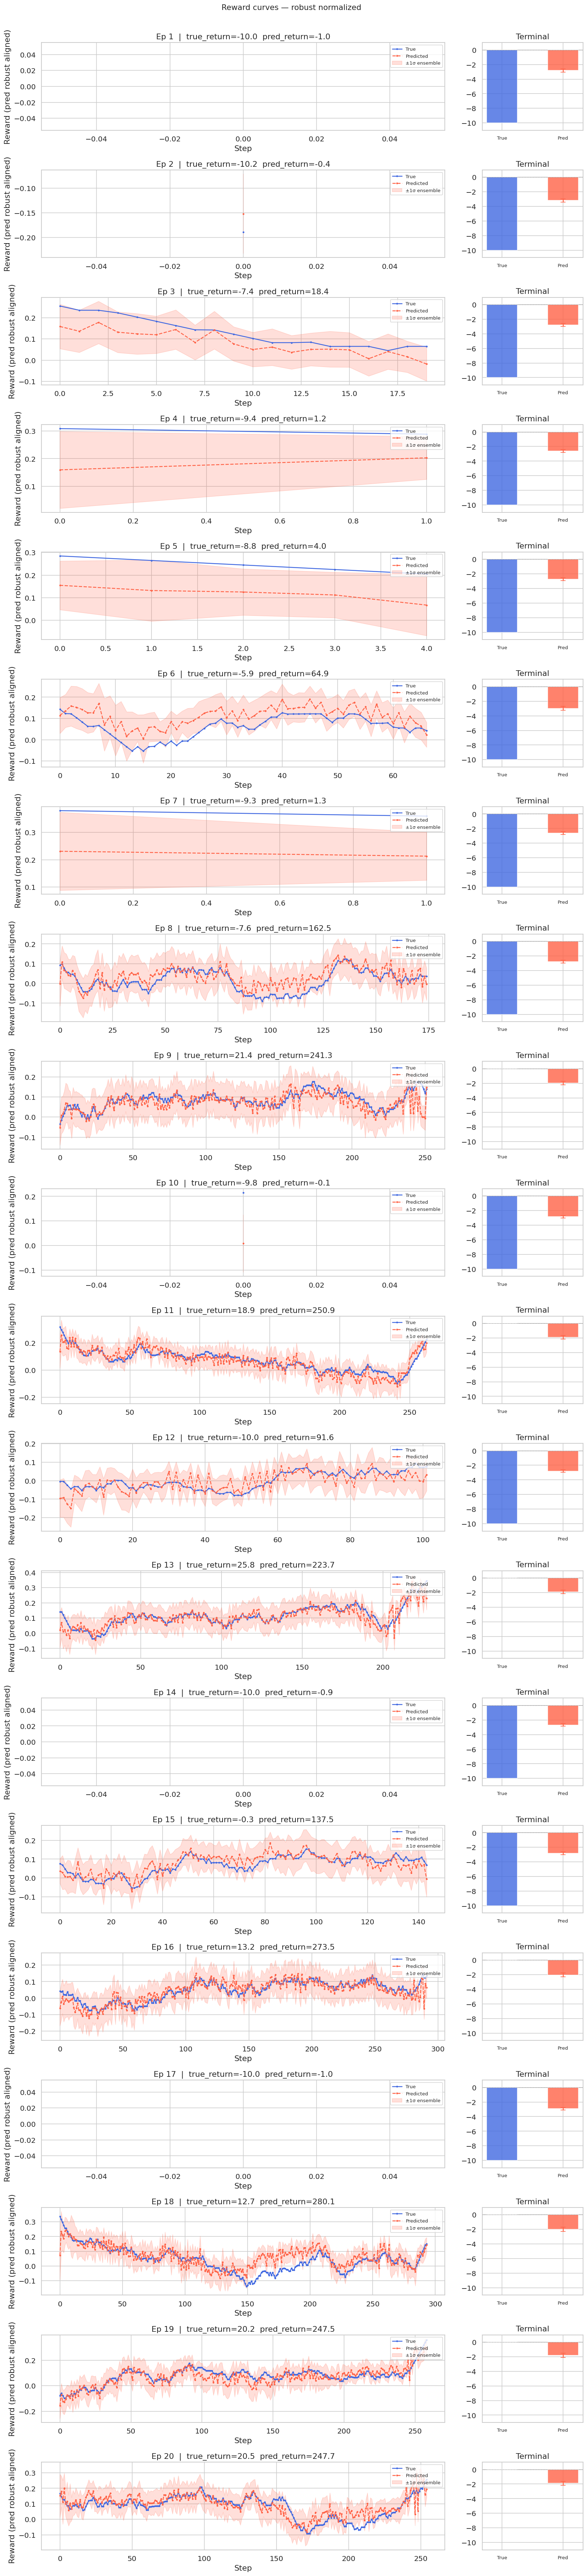

In [10]:
plot_reward_curves(trajectories[0:20], reward_model, normalize=True, robust=True)